# TESPy tutorial: Geothermal ORC

In this tutorial we build a tespy model step by step and explore a couple of 
the software's features. The plant uses 100 kg/s geothermal brine at 140 °C to
evaporate isopentane. An air cooled condenser rejects the waste heat.

![ORC flowsheet](orc_w_labels.svg)

The labels are the ones used in the code below.

## Step 1: imports, Network and units

First, import all necessary dependencies. The `Network` class is the container
for each model, the units specify the default unit system.

In [1]:
from tespy.networks import Network
from tespy.components import (
    Source, Sink,
    Pump, Turbine,
    MovingBoundaryHeatExchanger,
    CycleCloser,
    PowerSink, PowerBus,
    Motor, Generator
)
from tespy.connections import Connection, PowerConnection

import matplotlib.pyplot as plt

In [2]:
nw = Network()

nw.units.set_defaults(
    temperature="degC", pressure="bar", pressure_difference="bar",
    enthalpy="kJ/kg", mass_flow="kg/s", power="kW", heat="kW"
)

## Step 2: components

Next, we create the components of the cycle as shown in the flowsheet. The
`CycleCloser` is used to close a loop.

In [3]:
# the working fluid cycle
turbine = Turbine("turbine")
condenser = MovingBoundaryHeatExchanger("condenser")
pump = Pump("pump")
evaporator = MovingBoundaryHeatExchanger("evaporator")
cc = CycleCloser("cc")

# where the fluids come from and go
geothermal_source = Source("geothermal_source")
geothermal_sink = Sink("geothermal_sink")
air_source = Source("air_source")
air_sink = Sink("air_sink")

# the power train
generator = Generator("generator")
motor = Motor("motor")
power_bus = PowerBus("bus", num_in=1, num_out=2)
grid = PowerSink("grid")

**Checkpoint 1**: open `checkpoints/checkpoint_1_components.ipynb`, run all
cells and continue from here

## Step 3: fluid connections

The `Connection` class instances are used to link an outlet of a component to
the inlet of a different one. They carry the fluid information and variables
for the solver: mass flow, pressure, enthalpy and fluid composition.

In [4]:
# geothermal water: through the hot side of the evaporator
a1 = Connection(geothermal_source, "out1", evaporator, "in1", label="a1")
a2 = Connection(evaporator, "out1", geothermal_sink, "in1", label="a2")

# working fluid: the closed loop, opened once by the cycle closer
b1 = Connection(cc, "out1", turbine, "in1", label="b1")
b2 = Connection(turbine, "out1", condenser, "in1", label="b2")
b3 = Connection(condenser, "out1", pump, "in1", label="b3")
b4 = Connection(pump, "out1", evaporator, "in2", label="b4")
b5 = Connection(evaporator, "out2", cc, "in1", label="b5")

# ambient air: through the cold side of the condenser
c1 = Connection(air_source, "out1", condenser, "in2", label="c1")
c2 = Connection(condenser, "out2", air_sink, "in1", label="c2")

nw.add_conns(a1, a2, b1, b2, b3, b4, b5, c1, c2)

## Step 4: power connections

The `PowerConnection` class instances are used to represent non-material energy
flow between components, e.g. electrical and mechanical energy. They only
represent a single variable for the solver, i.e. the energy flow.

In [5]:
e1 = PowerConnection(turbine, "power", generator, "power_in", label="e1")
e2 = PowerConnection(generator, "power_out", power_bus, "power_in1", label="e2")
e3 = PowerConnection(power_bus, "power_out1", motor, "power_in", label="e3")
e4 = PowerConnection(motor, "power_out", pump, "power", label="e4")
e5 = PowerConnection(power_bus, "power_out2", grid, "power", label="e5")

nw.add_conns(e1, e2, e3, e4, e5)

**Checkpoint 2**: open `checkpoints/checkpoint_2_connections.ipynb`, run all
cells and continue from here

## Step 5: parameters

To solve a model subject to the boundary conditions we need to make sure, every
mass flow, pressure, enthalpy, fluid composition and energy flow can be 
determined from our specifications. We implement the following boundary
conditions:

| where | specification | meaning |
| --- | --- | --- |
| `a1` | `fluid`, `T=140`, `p=10`, `m=100` | geothermal source conditions |
| `b1` | `fluid`, `x=1`, `T=105` | saturated vapour at turbine inlet |
| `b3` | `td_bubble=5` | 5 K subcooling after the condenser |
| `c1`, `c2` | `T=10` / `T=20` | ambient air heated from 10 to 20 °C |
| turbine, pump | `eta_s` | isentropic efficiencies |
| generator, motor | `eta` | power train losses |
| heat exchangers | `dp1=0`, `dp2=0` | no pressure losses |
| condenser, evaporator | `td_pinch` | minimum temperature difference between flows |


In [6]:
a1.set_attr(fluid={"water": 1}, T=140, p=10, m=100)

b1.set_attr(fluid={"Isopentane": 1}, x=1, T=105)

b3.set_attr(td_bubble=5)

c1.set_attr(fluid={"air": 1}, T=10, p=1)
c2.set_attr(T=20)

In [7]:
turbine.set_attr(eta_s=0.8)
pump.set_attr(eta_s=0.7)

generator.set_attr(eta=0.98)
motor.set_attr(eta=0.98)

condenser.set_attr(dp1=0, dp2=0)
evaporator.set_attr(dp1=0, dp2=0)

condenser.set_attr(td_pinch=5)
evaporator.set_attr(td_pinch=8)

**Checkpoint 3**: open `checkpoints/checkpoint_3_parametrized.ipynb`, run all
cells and continue from here

## Step 6: solve

We solve the model by calling `nw.solve()`, `nw.print_results()` provides an
overview of the most important results.

In [8]:
nw.solve("design")

 block   0 | square          | iterations:   7 | residual: 6.76e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 4.95e-16 | pump.eta_s
 block   2 | scalar          | iterations:   4 | residual: 4.63e-10 | evaporator.td_pinch
 block   3 | scalar          | iterations:   3 | residual: 0.00e+00 | evaporator.energy_balance_constraints
 block   4 | scalar          | iterations:   3 | residual: 0.00e+00 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   3 | residual: 1.03e-17 | pump.energy_connector_balance
 block   6 | scalar          | iterations:   3 | residual: 0.00e+00 | turbine.energy_connector_balance
 block   7 | scalar          | iterations:   3 | residual: 0.00e+00 | bus.energy_balance_constraint


### Results

In [9]:
nw.print_results()


##### RESULTS (CycleCloser) #####
+----+------------------+-------------------+
|    |   mass_deviation |   fluid_deviation |
|----+------------------+-------------------|
| cc |         0.00e+00 |          0.00e+00 |
+----+------------------+-------------------+
##### RESULTS (MovingBoundaryHeatExchanger) #####
+------------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+----------+----------+------------+----------+------------+----------+-----------+------------+-----------+------------+
|            |         Q |       UA |       kA |   td_log |     lmtd |    ttd_u |    ttd_l |   ttd_min |      pr1 |      pr2 |      dp1 |      dp2 |   zeta1_d4 |    zeta1 |   zeta2_d4 |    zeta2 |   eff_hot |   eff_cold |   eff_max |   td_pinch |
|------------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+----------+----------+------------+----------+------------+------

We can also extract specific results or do some postprocessing:

In [10]:
print(f"net power:           {e5.E.val:8.1f} kW")
print(f"heat input:          {abs(evaporator.Q.val):8.1f} kW")
print(f"thermal efficiency:  {e5.E.val / abs(evaporator.Q.val) * 100:8.2f} %")
print(f"working fluid flow:  {b1.m.val:8.2f} kg/s")
print(f"brine outlet:        {a2.T.val:8.2f} degC")

net power:             2665.0 kW
heat input:           20639.1 kW
thermal efficiency:     12.91 %
working fluid flow:     42.75 kg/s
brine outlet:           91.29 degC


### Heat exchangers

We can plot Q-T diagrams to show the heat exchanger pinches

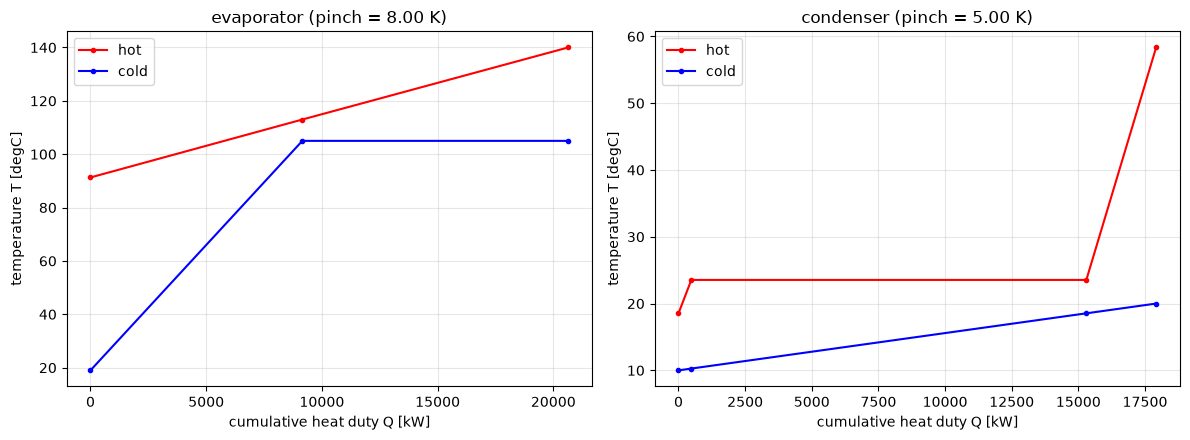

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, heatex in zip(axs, ["evaporator", "condenser"]):
    comp = nw.get_comp(heatex)
    ax.plot(comp.Q_sections.val, comp.T_hot_sections.val, "r-o", ms=3, label="hot")
    ax.plot(comp.Q_sections.val, comp.T_cold_sections.val, "b-o", ms=3, label="cold")
    ax.set_title(f"{heatex} (pinch = {comp.td_pinch.val:.2f} K)")
    ax.set_xlabel("cumulative heat duty Q [kW]")
    ax.set_ylabel("temperature T [degC]")
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()

We can change specifications and reuse the old model. E.g. instead of brine
mass flow the desired power output to know the required brine mass flow:

In [12]:
a1.set_attr(m=None)
e5.set_attr(E=3e3)
nw.solve("design")

 block   0 | square          | iterations:   2 | residual: 6.52e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 6.70e-17 | pump.eta_s
 block   2 | square          | iterations:   3 | residual: 0.00e+00 | bus.energy_balance_constraint, pump.energy_connector_balance, turbine.energy_connector_balance
 block   3 | scalar          | iterations:   2 | residual: 1.04e-09 | evaporator.td_pinch
 block   4 | scalar          | iterations:   2 | residual: 3.52e-15 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   3 | residual: 0.00e+00 | evaporator.energy_balance_constraints


In [13]:
print(f"net power:           {e5.E.val:8.1f} kW")
print(f"brine mass flow:     {a1.m.val:8.1f} kg/s")
print(f"heat input:          {abs(evaporator.Q.val):8.1f} kW")
print(f"thermal efficiency:  {e5.E.val / abs(evaporator.Q.val) * 100:8.2f} %")
print(f"working fluid flow:  {b1.m.val:8.2f} kg/s")
print(f"brine outlet:        {a2.T.val:8.2f} degC")

net power:             3000.0 kW
brine mass flow:        112.6 kg/s
heat input:           23233.3 kW
thermal efficiency:     12.91 %
working fluid flow:     48.13 kg/s
brine outlet:           91.29 degC


And switch back again.

In [14]:
a1.set_attr(m=100)
e5.set_attr(E=None)

## Step 7: Debugging

We can debug a model, in case failures happen during solving. For this, we
deliberately specify boundary conditions that lead to failures.

### Overdetermination of mass flow

We can specify an extra boundary condition, i.e. working fluid mass flow, and
try to solve again:

In [15]:
b1.set_attr(m=50)
nw.solve("design")

You have provided too many parameters: 9 required, 10 supplied. Aborting calculation!
The original problem holds 41 variables, 7 directly specified, and 35 equations. Presolving consumed 25 equations and reduced the problem to 9 variables and 10 equations.
Structural analysis - the problem contains an over-determined part (6 equations competing for 5 variables).
Inspect the problem with
  - nw.print_structural_analysis() for the over- or under-determined part of the model,
  - nw.print_variables() and nw.print_equations() for the variables and equations that are present,
  - nw.print_equations_with_dependents() for the variables each equation depends on,
  - nw.print_incidence_matrix() for a compact overview.


TESPyNetworkError: You have provided too many parameters: 9 required, 10 supplied. Aborting calculation!
The original problem holds 41 variables, 7 directly specified, and 35 equations. Presolving consumed 25 equations and reduced the problem to 9 variables and 10 equations.
Structural analysis - the problem contains an over-determined part (6 equations competing for 5 variables).
Inspect the problem with
  - nw.print_structural_analysis() for the over- or under-determined part of the model,
  - nw.print_variables() and nw.print_equations() for the variables and equations that are present,
  - nw.print_equations_with_dependents() for the variables each equation depends on,
  - nw.print_incidence_matrix() for a compact overview.

In [16]:
nw.print_structural_analysis()

Over-determined part - the following equations compete for the involved variables:
  Equations: condenser.td_pinch, evaporator.energy_balance_constraints, evaporator.td_pinch, pump.eta_s, turbine.eta_s, b3.td_bubble
  Involved variables: h0, h2, h3, h4, p6


We can undo our wrong specification and instead specify a unsatisfyable boudary
condition, e.g. a pinch of 40 K. This leads to non-convergence, since the 
residual of the pinch equation can never be satisfied.

In [17]:
b1.set_attr(m=None)
evaporator.set_attr(td_pinch=40)
nw.solve("design")

Block 2 did not converge, solving the remaining 6 blocks simultaneously.
  Cause: no acceptance within the iteration budget of 50 iterations, the last scaled residual is 5.00e+00
  Equations: evaporator.td_pinch
  Variables: h0


 block   0 | square          | iterations:   2 | residual: 6.76e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 8.37e-17 | pump.eta_s
 block   2 | scalar          | iterations:  50 | residual: 5.00e+00 | evaporator.td_pinch


The remaining system did not converge either, restarting with the simultaneous solution of the full system from its initial state.


 block   2 | remainder       | iterations:  50 | residual: 5.00e+00 | 6 equations

 iter  | residual   | progress   | massflow   | pressure   | enthalpy   | fluid      | energy     | component  
-------+------------+------------+------------+------------+------------+------------+------------+------------
 1     | 5.65e-01   | 3 %        | 2.32e+03   | 6.05e-08   | 2.43e+05   | 0.00e+00   | 5.04e+06   | 0.00e+00   
 2     | 5.00e+00   | 0 %        | 4.32e-02   | 1.78e-10   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 3     | 5.00e+00   | 0 %        | 4.32e-02   | 1.82e-12   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 4     | 5.00e+00   | 0 %        | 4.32e-02   | 1.86e-12   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 5     | 5.00e+00   | 0 %        | 4.32e-02   | 1.86e-12   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 6     | 5.00e+00   | 0 %        | 4.32e-02   | 1.86e-12   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 7     | 5.00e+00   |

The solver does not seem to make any progress, aborting calculation. Scaled residual value is 5.00e+00 (evaporator: td_pinch)
Possible reasons include:
 - fluid properties moving outside the valid range of the property database (consider adjusting p_range or h_range),
 - an impossible constraint that can never be satisfied 
 - bad starting values causing the Newton solver to diverge.
Use nw.print_residuals() to identify which equations have the largest residuals.


 38    | 5.00e+00   | 0 %        | 4.32e-02   | 6.03e-08   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 39    | 5.00e+00   | 0 %        | 4.32e-02   | 6.04e-08   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 40    | 5.00e+00   | 0 %        | 4.32e-02   | 6.04e-08   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 41    | 5.00e+00   | 0 %        | 4.32e-02   | 6.04e-08   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
 42    | 5.00e+00   | 0 %        | 4.32e-02   | 3.71e-12   | 5.00e+00   | 0.00e+00   | 9.35e+01   | 0.00e+00   
Total iterations: 42, Calculation time: 2.41 s, Iterations per second: 17.39


In [18]:
nw.print_residuals()

Residuals per equation (10 total, sorted by scaled magnitude):
  Eq#  Object      Equation                       Scaled    Residual
-----  ----------  --------------------------  ---------  ----------
    4  evaporator  td_pinch                    5.000e+00   5.000e+00
    0  bus         energy_balance_constraint   1.052e-11   1.024e-05
    7  turbine     energy_connector_balance    7.999e-13  -3.213e-06
    5  pump        energy_connector_balance    4.786e-14   1.590e-08
    1  condenser   energy_balance_constraints  1.306e-14   1.248e-07
    9  b3          td_bubble                   4.558e-15  -1.705e-13
    6  pump        eta_s                       9.744e-16  -2.774e-11
    8  turbine     eta_s                       1.704e-17   7.276e-12
    3  evaporator  energy_balance_constraints  7.009e-18   4.657e-10
    2  condenser   td_pinch                    0.000e+00   0.000e+00


In [19]:
evaporator.set_attr(td_pinch=8)
nw.solve("design")

 block   0 | square          | iterations:   2 | residual: 6.76e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 8.37e-17 | pump.eta_s
 block   2 | scalar          | iterations:   2 | residual: 2.37e-14 | evaporator.td_pinch
 block   3 | scalar          | iterations:   2 | residual: 8.53e-15 | evaporator.energy_balance_constraints
 block   4 | scalar          | iterations:   2 | residual: 5.92e-15 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   3 | residual: 1.45e-17 | pump.energy_connector_balance
 block   6 | scalar          | iterations:   3 | residual: 0.00e+00 | turbine.energy_connector_balance
 block   7 | scalar          | iterations:   3 | residual: 0.00e+00 | bus.energy_balance_constraint


## Step 8: design and off-design

It is possible to run design and offdesign simulations. E.g. how large is the
evaporator to achieve a pinch of 8 K. The `UA` value is the result of that
boundary condition.

In offdesign simulation mode we invert that, i.e. the `UA` value might be a
fixed input and the pinch becomes a result. 

TESPy does not provide you with help on what to switch from design to
offdesign, it is entirely your knowledge about the system to make this
decision.

In [20]:
evaporator.set_attr(design=["td_pinch"], offdesign=["UA"])
nw.solve("design")
design_state = nw.save(as_dict=True)

 block   0 | square          | iterations:   2 | residual: 6.90e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 3.35e-17 | pump.eta_s
 block   2 | scalar          | iterations:   2 | residual: 4.17e-14 | evaporator.td_pinch
 block   3 | scalar          | iterations:   2 | residual: 0.00e+00 | evaporator.energy_balance_constraints
 block   4 | scalar          | iterations:   2 | residual: 0.00e+00 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   2 | residual: 0.00e+00 | pump.energy_connector_balance
 block   6 | scalar          | iterations:   2 | residual: 0.00e+00 | turbine.energy_connector_balance
 block   7 | scalar          | iterations:   2 | residual: 0.00e+00 | bus.energy_balance_constraint


In [21]:
print(f"design:     UA = {evaporator.UA.val / 1e3:7.1f} kW/K  (result)")
print(f"            pinch = {evaporator.td_pinch.val:5.2f} K  (specified)")

design:     UA =   941.2 kW/K  (result)
            pinch =  8.00 K  (specified)


Now we run the simulation in offdesign mode in which the `UA` value of the
evaporator is fixed to its design point value. We can change the mass flow and
see how the pinch changes.

In [22]:
a1.set_attr(m=80)
nw.solve("offdesign", design_path=design_state)

 block   0 | square          | iterations:   2 | residual: 6.81e-11 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 6.70e-17 | pump.eta_s
 block   2 | square          | iterations:   6 | residual: 8.77e-15 | evaporator.energy_balance_constraints, evaporator.UA
 block   3 | scalar          | iterations:   2 | residual: 8.04e-15 | condenser.energy_balance_constraints
 block   4 | scalar          | iterations:   2 | residual: 1.31e-16 | pump.energy_connector_balance
 block   5 | scalar          | iterations:   2 | residual: 2.23e-15 | turbine.energy_connector_balance
 block   6 | scalar          | iterations:   3 | residual: 0.00e+00 | bus.energy_balance_constraint


In [23]:
print(f"off-design: UA = {evaporator.UA.val / 1e3:7.1f} kW/K  (specified)")
print(f"            pinch = {evaporator.td_pinch.val:5.2f} K  (result)")
print(f"            {a1.m.val} kg/s brine -> {e5.E.val:.1f} kW")

off-design: UA =   941.2 kW/K  (specified)
            pinch =  5.61 K  (result)
            80.0 kg/s brine -> 2319.5 kW


When reducing the mass flow, the pinch reduces as the same heat exchange area
is available as in the design simulation but less heat is transferred due to
the lower mass flow.

After this, we go back to the original value of `td_pinch` and run a design
simulation.

In [24]:
a1.set_attr(m=100)

# the off-design run left its own result in td_pinch - a design
# parameter keeps whatever value it currently holds, so set it again
evaporator.set_attr(td_pinch=8)

nw.solve("design")

 block   0 | square          | iterations:   2 | residual: 2.02e-12 | condenser.td_pinch, turbine.eta_s, b3.td_bubble
 block   1 | scalar          | iterations:   2 | residual: 5.02e-17 | pump.eta_s
 block   2 | scalar          | iterations:   4 | residual: 1.04e-09 | evaporator.td_pinch
 block   3 | scalar          | iterations:   3 | residual: 2.64e-14 | evaporator.energy_balance_constraints
 block   4 | scalar          | iterations:   2 | residual: 8.84e-15 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   2 | residual: 1.82e-15 | pump.energy_connector_balance
 block   6 | scalar          | iterations:   3 | residual: 0.00e+00 | turbine.energy_connector_balance
 block   7 | scalar          | iterations:   3 | residual: 5.19e-14 | bus.energy_balance_constraint


## Step 9: modeling flexibility

TESPy provides you with a lot of flexibility in modeling: You can implement
relations into your model, that are not available from the library. For this
the `UserDefinedEquation` is used. 

Suppose, you want to maximize the power output of the ORC plant. A rough
estimation for the optimal evaporation temperature can be given by a rule of
thumb: the optimum sits near the **geometric mean** of source and sink
temperature in Kelvin [1]:

$$T_\text{evaporation} \approx \sqrt{T_\text{source} \cdot
T_\text{sink}}$$

We can implement this equation in its residual form as an extra boundary
condition to replace the direct temperature specification at the evaporator
outlet.

In [25]:
from tespy.tools import UserDefinedEquation


def geometric_mean(ude):
    """0 = T_evaporation - sqrt(T_source * T_sink)"""
    source, evaporation, sink = ude.conns
    return evaporation.calc_T() - (source.calc_T() * sink.calc_T()) ** 0.5


def dependents(ude):
    """Return a list of variables, the equation depends on"""
    source, evaporation, sink = ude.conns
    return [
        source.p, source.h, evaporation.p, evaporation.h, sink.p, sink.h
    ]

In [26]:
b1.set_attr(T=None)

rule = UserDefinedEquation(
    "optimal evaporation temperature",
    geometric_mean,
    dependents,
    conns=[a1, b1, b3],
)
nw.add_ude(rule)

nw.solve("design")

 block   0 | square          | iterations:   5 | residual: 1.41e-10 | condenser.td_pinch, turbine.eta_s, b1.x, b3.td_bubble, optimal evaporation temperature.equation
 block   1 | scalar          | iterations:   2 | residual: 5.11e-17 | pump.eta_s
 block   2 | scalar          | iterations:   4 | residual: 1.74e-10 | evaporator.td_pinch
 block   3 | scalar          | iterations:   3 | residual: 0.00e+00 | evaporator.energy_balance_constraints
 block   4 | scalar          | iterations:   3 | residual: 0.00e+00 | condenser.energy_balance_constraints
 block   5 | scalar          | iterations:   3 | residual: 0.00e+00 | pump.energy_connector_balance
 block   6 | scalar          | iterations:   2 | residual: 4.67e-15 | turbine.energy_connector_balance
 block   7 | scalar          | iterations:   3 | residual: 0.00e+00 | bus.energy_balance_constraint


In [27]:
print(f"source                  {a1.T.val:7.2f} degC")
print(f"sink                    {b3.T.val:7.2f} degC")
print(f"evaporation (the rule)  {b1.T.val:7.2f} degC")
print()
print(f"net power               {e5.E.val:7.1f} kW   (was 2665.0 at 105 degC)")
print(f"thermal efficiency      {e5.E.val / abs(evaporator.Q.val) * 100:7.2f} %    (was 12.91)")

source                   140.00 degC
sink                      19.10 degC
evaporation (the rule)    74.33 degC

net power                3294.3 kW   (was 2665.0 at 105 degC)
thermal efficiency         9.41 %    (was 12.91)


With the changed evaporation temperature we yield higher power output at a 
decreased efficiency. This is possible as we are able to remove more heat from
the brine flow. 

Next, with a small sensitivity analysis we can check, how good the rule of
thumb is. We remove the additional equation again and instead loop over 
different evaporation temperatures.

In [28]:
nw.del_ude(rule)

nw.iterinfo = False

results = {}
for T in [65, 70, 74.33, 80, 85, 90, 95, 100, 105]:
    b1.set_attr(T=T)
    nw.solve("design")
    if nw.status == 0:
        results[T] = (e5.E.val, e5.E.val / abs(evaporator.Q.val) * 100)

In [29]:
print(" T_evap    P_net      eta_th")
for T, (P, eta) in results.items():
    mark = "  <- the rule" if T == 74.33 else ""
    print(f"{T:6.2f} {P:9.1f} kW {eta:7.2f} %{mark}")

best = max(results, key=lambda T: results[T][0])
print(f"\nmaximum power at {best} degC: {results[best][0]:.1f} kW")

 T_evap    P_net      eta_th
 65.00    3066.9 kW    8.05 %
 70.00    3211.9 kW    8.79 %
 74.33    3294.3 kW    9.41 %  <- the rule
 80.00    3340.7 kW   10.16 %
 85.00    3322.7 kW   10.78 %
 90.00    3248.1 kW   11.36 %
 95.00    3115.2 kW   11.91 %
100.00    2921.7 kW   12.43 %
105.00    2665.0 kW   12.91 %

maximum power at 80 degC: 3340.7 kW


The rule of thumb is quite close in terms of absolute power output to the
actual optimum.

## Reference

**[1]** Curzon, F. L. and Ahlborn, B. (1975). *Efficiency of a Carnot engine at
maximum power output.* American Journal of Physics 43(1), 22-24.
doi: [10.1119/1.10023](https://doi.org/10.1119/1.10023)